<a href="https://colab.research.google.com/github/WVF-1/Urban-Tree-Modeling/blob/main/Interpretation_and_Widget.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4 — Growing Better Cities
## Part 2 of 3: Interpretation & the Planning Widget

**Building Data Together Data Science Newsletter**

Notebook 1 built and honestly evaluated a Random Forest predicting tree density (`trees_per_km2`) from land-use and geography features. This notebook opens the model up:

1. Feature importance — impurity-based *and* permutation-based (the two don't always agree, and that disagreement is itself informative)
2. Partial dependence — how the model's prediction moves as each feature changes, holding others fixed
3. SHAP — per-city explanations of *why* the model predicts what it predicts
4. **The planning widget** — sliders for park %, impervious %, population density, elevation, and water %, with a live predicted tree-density readout. This is the "show, don't just tell" piece for urban planners.


## 0. Setup

In [1]:
!pip install -q shap ipywidgets

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import joblib
import shap
import ipywidgets as widgets
from IPython.display import display

from sklearn.inspection import permutation_importance, PartialDependenceDisplay

sns.set_theme(style="whitegrid", font_scale=1.05)
NATURAL_PALETTE = ["#2E5339", "#6B8E4E", "#A9BA9D", "#C9A66B", "#8C6239", "#4A3728"]
sns.set_palette(NATURAL_PALETTE)
NATURAL_CMAP = mcolors.LinearSegmentedColormap.from_list("natural", ["#C9A66B", "#6B8E4E", "#2E5339"])

RANDOM_STATE = 42


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 29.5 MB/s eta 0:00:00


## 1. Load model, data, and metadata from Notebook 1

In [2]:
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Upload week4_rf_model.joblib, week4_predictions.csv, and week4_model_metadata.json")
    uploaded = files.upload()

model = joblib.load("week4_rf_model.joblib")
predictions_df = pd.read_csv("week4_predictions.csv")
with open("week4_model_metadata.json") as f:
    meta = json.load(f)

FEATURE_NAMES = meta["feature_names"]
NUMERIC_FEATURES = meta["numeric_features"]
TARGET = meta["target"]

X = pd.get_dummies(
    predictions_df[NUMERIC_FEATURES + ["region"]], columns=["region"], drop_first=True
).reindex(columns=FEATURE_NAMES, fill_value=0)
y = predictions_df[TARGET].values

print(f"Loaded model trained on {meta['n_cities']} cities, LOOCV R2 = {meta['loo_r2']:.3f}")
X.head()


Upload week4_rf_model.joblib, week4_predictions.csv, and week4_model_metadata.json


Saving week4_model_metadata.json to week4_model_metadata.json
Saving week4_predictions.csv to week4_predictions.csv
Saving week4_rf_model.joblib to week4_rf_model.joblib
Loaded model trained on 12 cities, LOOCV R2 = -0.126


,elevation_m,population_density_per_km2,pct_impervious_proxy,pct_parkland,pct_water,population,region_Northeast,region_South,region_West
0,1587.0,1073.460579,0.428055,0.101283,0.008644,556495,False,False,True
1,61.0,2620.057374,0.433079,0.048618,0.028259,345012,False,False,True
2,190.0,1469.783272,0.537761,0.035914,0.044521,379577,False,True,False
3,336.0,1271.349084,0.694056,0.037766,0.007924,447841,False,True,False
4,1652.0,828.961278,0.303586,0.036362,0.013026,345803,False,False,True


## 2. Feature importance: impurity-based vs. permutation-based

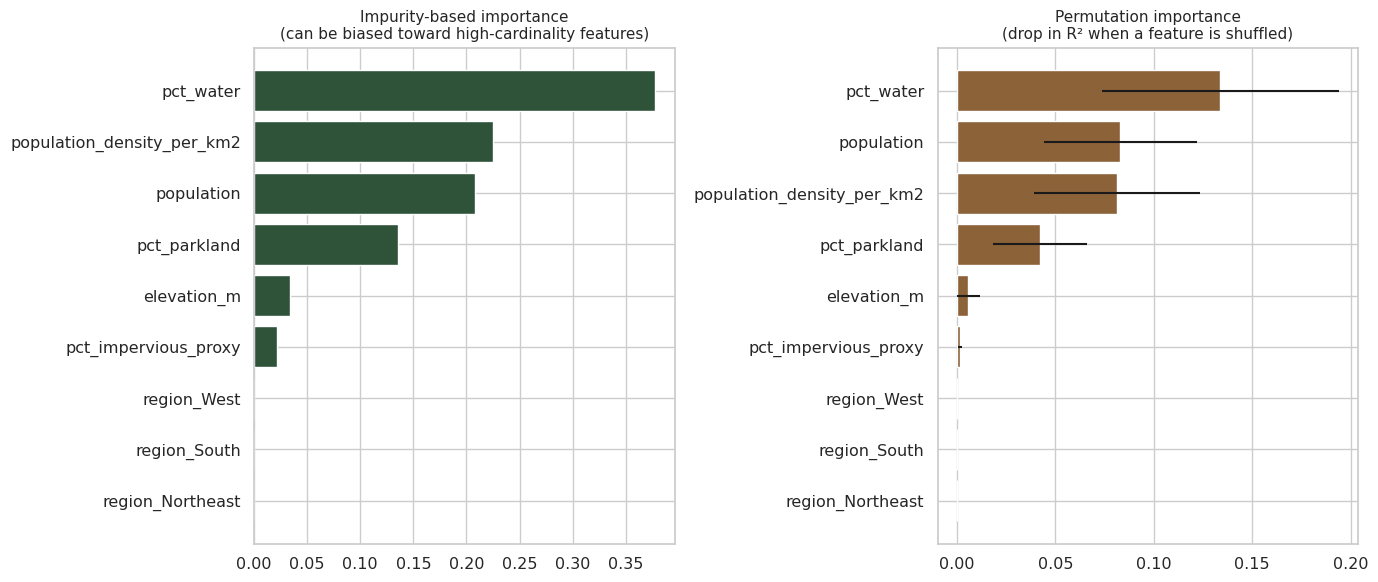

In [3]:
impurity_importance = pd.Series(model.feature_importances_, index=FEATURE_NAMES).sort_values()

perm_result = permutation_importance(
    model, X, y, n_repeats=50, random_state=RANDOM_STATE, scoring="r2"
)
perm_importance = pd.Series(perm_result.importances_mean, index=FEATURE_NAMES).sort_values()
perm_std = pd.Series(perm_result.importances_std, index=FEATURE_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(impurity_importance.index, impurity_importance.values, color=NATURAL_PALETTE[0])
axes[0].set_title("Impurity-based importance\n(can be biased toward high-cardinality features)", fontsize=11)

axes[1].barh(
    perm_importance.index, perm_importance.values,
    xerr=perm_std.reindex(perm_importance.index), color=NATURAL_PALETTE[4],
)
axes[1].set_title("Permutation importance\n(drop in R² when a feature is shuffled)", fontsize=11)

plt.tight_layout()
plt.savefig("week4_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


If these two rankings disagree substantially, trust permutation importance more — it directly measures predictive contribution rather than relying on how often a feature was used to split a tree.


## 3. Partial dependence: how does each feature move the prediction?

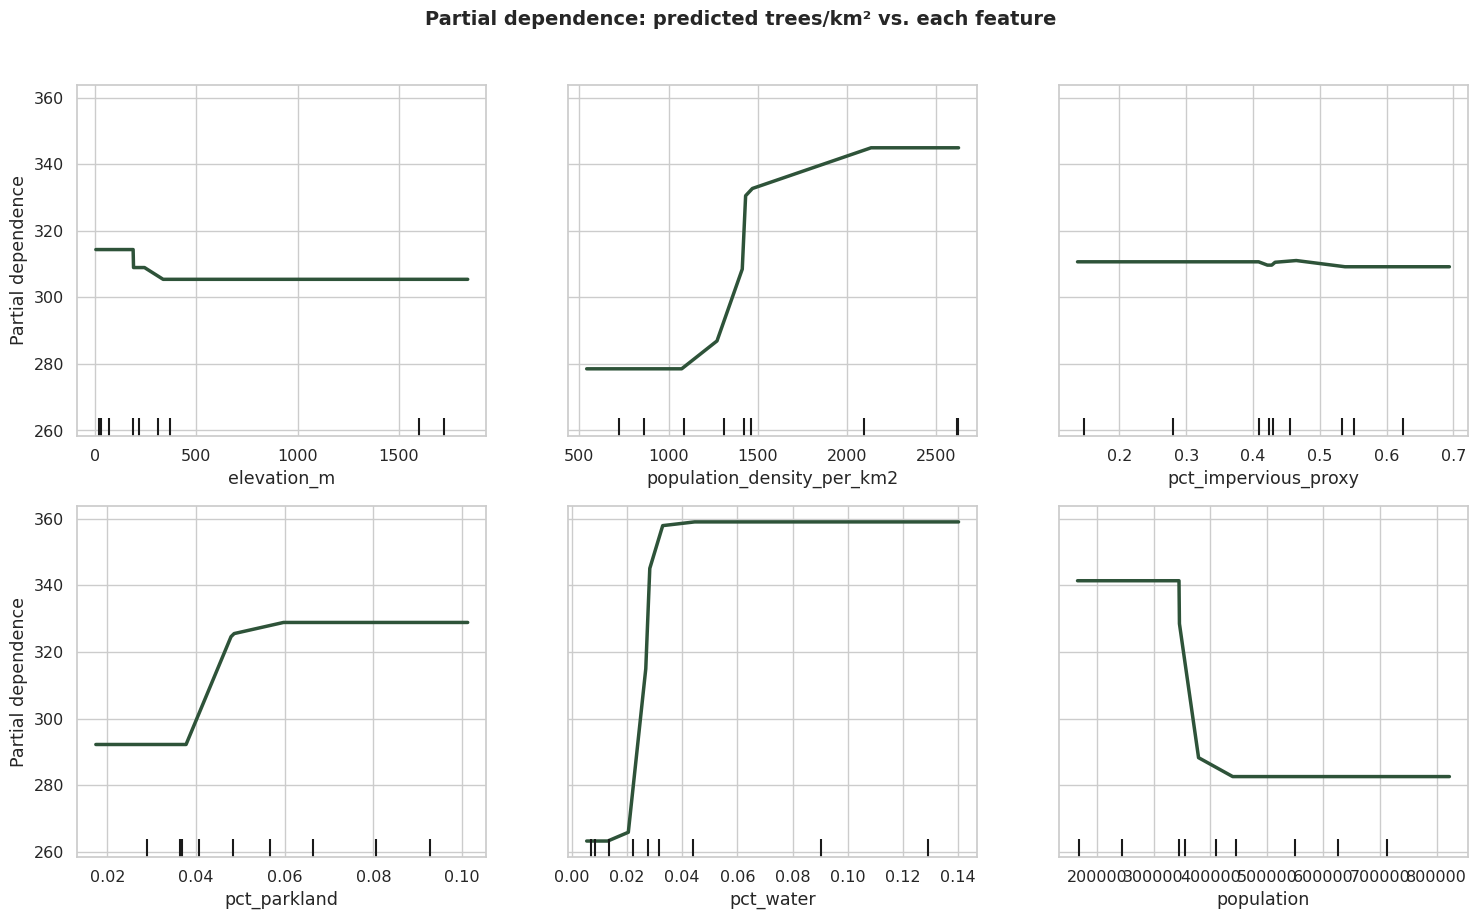

In [4]:
fig, ax = plt.subplots(figsize=(15, 9))
PartialDependenceDisplay.from_estimator(
    model, X, features=NUMERIC_FEATURES, ax=ax,
    line_kw={"color": NATURAL_PALETTE[0], "linewidth": 2.5},
)
plt.suptitle("Partial dependence: predicted trees/km² vs. each feature", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("week4_partial_dependence.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. SHAP: per-city explanations

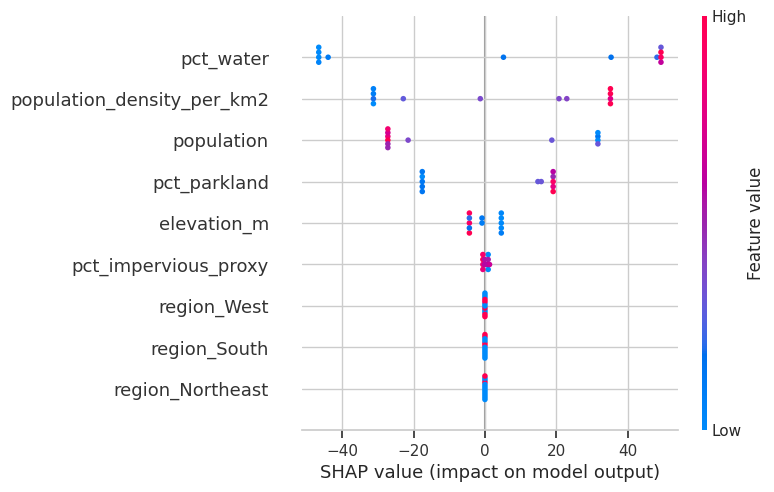

In [5]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)

fig = plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X, show=False, color=plt.get_cmap(NATURAL_CMAP))
plt.tight_layout()
plt.savefig("week4_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()



--- Buffalo ---
Actual: 1096  |  Predicted: 285  |  Residual: 812


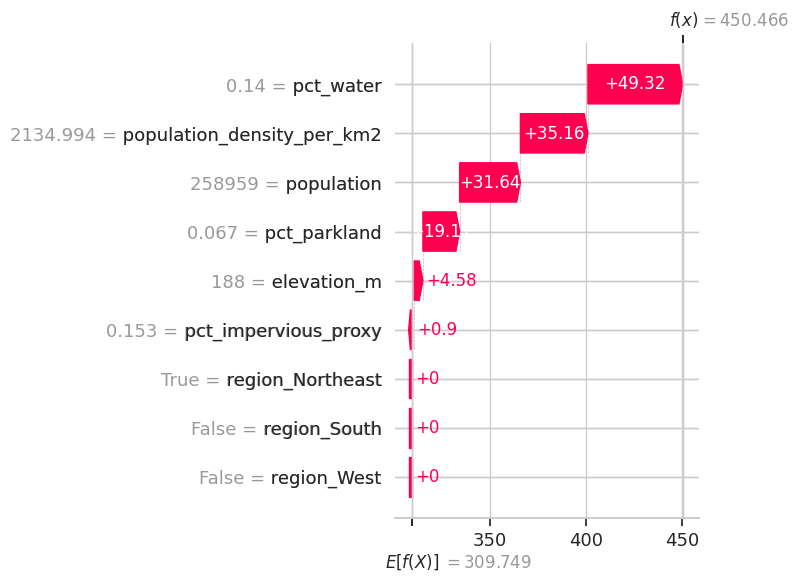


--- Boston ---
Actual: 5  |  Predicted: 400  |  Residual: -395


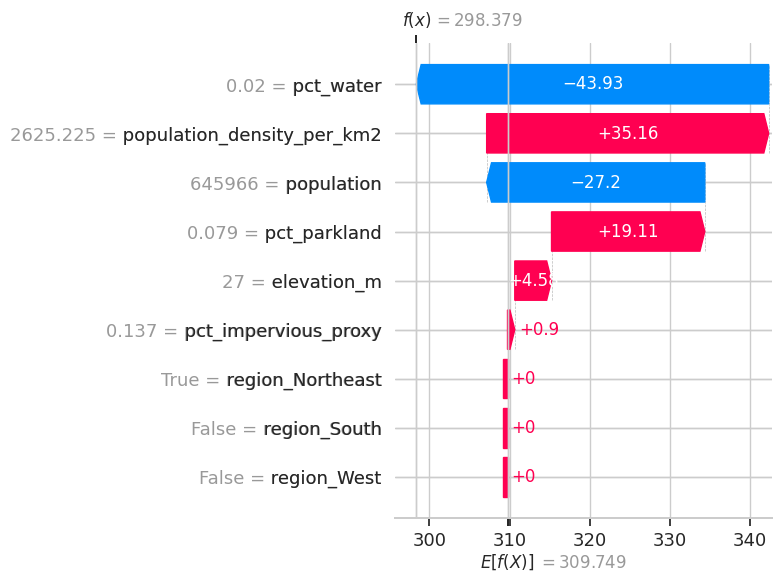

In [6]:
# Two example cities: pick the most over-performing and most under-performing
# relative to the model's prediction (from Notebook 1's residuals), as concrete
# case studies for the newsletter write-up.
example_idx = [
    predictions_df["residual"].idxmax(),
    predictions_df["residual"].idxmin(),
]

for idx in example_idx:
    city_name = predictions_df.loc[idx, "city"]
    print(f"\n--- {city_name} ---")
    print(f"Actual: {predictions_df.loc[idx, TARGET]:.0f}  |  "
          f"Predicted: {predictions_df.loc[idx, 'predicted_trees_per_km2']:.0f}  |  "
          f"Residual: {predictions_df.loc[idx, 'residual']:.0f}")
    shap.plots.waterfall(shap_values[idx], show=False)
    plt.tight_layout()
    plt.savefig(f"week4_shap_waterfall_{city_name.replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()


## 5. The planning widget

Move the sliders to simulate a hypothetical city (or start from a real one and nudge it) and watch the model's predicted tree density update live. This is the "teach, don't just tell" piece — a planner can see, directly, how much predicted tree density moves per percentage point of added park land, holding everything else fixed.

**Read this as a sensitivity exploration, not a guarantee** — the model has the honest LOOCV error bars from Notebook 1 baked into it; a "+400 trees/km²" swing on the slider should be read relative to that uncertainty, not as a precise promise.


In [7]:
def predict_from_inputs(elevation_m, population_density, pct_impervious, pct_parkland, pct_water, population, region):
    row = {f: 0 for f in FEATURE_NAMES}
    row["elevation_m"] = elevation_m
    row["population_density_per_km2"] = population_density
    row["pct_impervious_proxy"] = pct_impervious
    row["pct_parkland"] = pct_parkland
    row["pct_water"] = pct_water
    row["population"] = population
    region_col = f"region_{region}"
    if region_col in row:
        row[region_col] = 1
    x_row = pd.DataFrame([row])[FEATURE_NAMES]
    return model.predict(x_row)[0]


city_selector = widgets.Dropdown(
    options=predictions_df["city"].tolist(), description="Start from:",
    style={"description_width": "initial"},
)

elevation_slider = widgets.FloatSlider(value=200, min=0, max=2500, step=25, description="Elevation (m)")
density_slider = widgets.FloatSlider(value=2000, min=0, max=8000, step=100, description="Pop. density (/km²)")
impervious_slider = widgets.FloatSlider(value=0.4, min=0, max=0.9, step=0.01, description="Impervious %")
parkland_slider = widgets.FloatSlider(value=0.08, min=0, max=0.4, step=0.01, description="Parkland %")
water_slider = widgets.FloatSlider(value=0.03, min=0, max=0.3, step=0.01, description="Water %")
population_slider = widgets.FloatSlider(value=5e5, min=1e4, max=9e6, step=1e4, description="Population")
region_selector = widgets.Dropdown(
    options=sorted(predictions_df["region"].dropna().unique().tolist()), description="Region",
)

sliders = [elevation_slider, density_slider, impervious_slider, parkland_slider, water_slider, population_slider]
for s in sliders:
    s.style = {"description_width": "initial"}
    s.layout = widgets.Layout(width="480px")

output = widgets.Output()


def load_city(change=None):
    row = predictions_df[predictions_df["city"] == city_selector.value].iloc[0]
    elevation_slider.value = row["elevation_m"]
    density_slider.value = row["population_density_per_km2"]
    impervious_slider.value = row["pct_impervious_proxy"]
    parkland_slider.value = row["pct_parkland"]
    water_slider.value = row["pct_water"]
    population_slider.value = row["population"]
    region_selector.value = row["region"]


def update_prediction(change=None):
    baseline_row = predictions_df[predictions_df["city"] == city_selector.value].iloc[0]
    baseline_pred = baseline_row["predicted_trees_per_km2"]

    pred = predict_from_inputs(
        elevation_slider.value, density_slider.value, impervious_slider.value,
        parkland_slider.value, water_slider.value, population_slider.value,
        region_selector.value,
    )
    delta = pred - baseline_pred

    with output:
        output.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(7, 2.2))
        ax.barh(["Baseline\n(model, current)", "Scenario\n(sliders)"], [baseline_pred, pred],
                color=[NATURAL_PALETTE[2], NATURAL_PALETTE[0]])
        ax.set_xlim(0, max(baseline_pred, pred) * 1.25 + 1)
        for i, v in enumerate([baseline_pred, pred]):
            ax.text(v + 5, i, f"{v:.0f}", va="center", fontsize=11, fontweight="bold")
        ax.set_title(
            f"{city_selector.value}: predicted trees/km² — "
            f"scenario is {'+' if delta >= 0 else ''}{delta:.0f} vs. baseline",
            fontsize=11, fontweight="bold",
        )
        plt.tight_layout()
        plt.show()


city_selector.observe(load_city, names="value")
city_selector.observe(update_prediction, names="value")
for s in sliders + [region_selector]:
    s.observe(update_prediction, names="value")

load_city()
ui = widgets.VBox([
    city_selector,
    widgets.HTML("<b>Adjust the scenario:</b>"),
    *sliders, region_selector,
    output,
])
display(ui)
update_prediction()


## Notes for the writeup

- Lead with the SHAP waterfall case studies — they translate the model into a specific, concrete story ("here's why the model thinks City X has the tree density it has").
- The widget is the interactive centerpiece; a static screenshot won't do it justice in the newsletter, so consider embedding the live Colab link rather than just a plot.
- Keep repeating the honest framing: this ranks *levers*, it doesn't predict outcomes precisely. A planner using the slider to justify "we need exactly 12% more parkland" would be over-reading a 63-city exploratory model.

Next: Notebook 3 turns the residuals into a "who's over/under-performing" case-study map.
